In [4]:
import os
import sys, pathlib
import numpy as np

sys.path.append(os.path.join(os.path.expanduser('~'), 'Programming', 'In_Vivo','physion', 'src'))

from physion.utils import plot_tools as pt
from physion.analysis.read_NWB import Data, scan_folder_for_NWBfiles
from physion.dataviz.imaging import show_CaImaging_FOV
from physion.dataviz.raw import plot as plot_raw, find_default_plot_settings
#from physion.dataviz.raw import plot_test
from physion.dataviz import tools as dv_tools

import matplotlib.pyplot as plt

from scipy import stats
from physion.analysis.process_NWB import EpisodeData

base_path = os.path.join(os.path.expanduser('~'), 'DATA','In_Vivo_experiments','my_experiments', 'All_NWBs')

from physion.dataviz.episodes.trial_average import plot as plot_trial_average

import random

In [5]:
# Function to generate full paths
def generate_file_paths(filenames_list, base_path):
    return [os.path.join(base_path, filename) for filename in filenames_list]

# Function to load data and process
def load_and_process_data(filenames):
    data_list = []
    for filename in filenames:
        print(filename)
        data = Data(filename, verbose=False)
        data.build_dFoF(method_for_F0='sliding_percentile',
                        verbose=False)
        data_list.append(data)
    return data_list

def process_data(data):
    data.build_dFoF(method_for_F0='sliding_percentile',
                    verbose=False)
    setattr(data, 'new', 0)
    
def get_dFoF(the_list):
    dFoF_all = []
    for data in DATA_monitoring_keta:
        dFoF_all.append(data.dFoF)
    return dFoF_all

def check_group(the_list): #prints (number ROIs, number datapoints)
    for i in range(0, len(the_list)):
        print(the_list[i].dFoF.shape)

def average_ROIs(the_list):
    list_mean_ROIs = []
    for i in range(0, len(the_list)):
        mean_ROIs = np.mean(the_list[i].dFoF, axis=0)
        list_mean_ROIs.append(mean_ROIs)
        #print(mean_ROIs)
        #print(mean_ROIs.shape)
    return list_mean_ROIs

def pad_list(n_array):
    max_length = max(len(arr) for arr in n_array)
    padded_arrays = np.array([np.pad(arr, (0, max_length - len(arr)), constant_values=np.nan) for arr in n_array])
    #print(padded_arrays.shape)
    return padded_arrays



In [6]:
names_monitoring_keta = ["2024_10_07-16-26-15.nwb", "2024_10_11-14-13-22.nwb", "2024_10_11-15-46-32.nwb", "2024_10_11-17-26-55.nwb"]
names_8ori_keta       = ["2024_09_12-14-57-34.nwb", "2024_09_12-15-24-47.nwb", "2024_09_12-15-50-12.nwb", "2024_10_07-15-03-40.nwb", 
                         "2024_10_07-17-18-53.nwb", "2024_10_11-14-57-27.nwb", "2024_10_11-16-44-26.nwb", "2024_10_11-18-24-27.nwb"]
names_8ori_saline     = ["2024_08_27-12-21-14.nwb", "2024_08_27-12-46-41.nwb"]

# Monitoring keta

In [7]:
fns = generate_file_paths(names_monitoring_keta, base_path)
data = Data(fns[0], verbose=False)


calculating dF/F with method "percentile" [...]

  ** all ROIs passed the positive F0 criterion ** 

-> dFoF calculus done !  (calculation took 0.1s)


Text(0, 0.5, 'running speed (cm/s)')

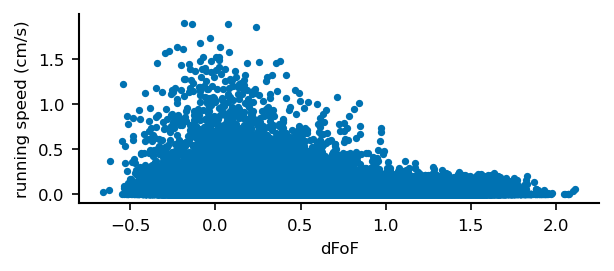

In [8]:
data.build_dFoF()
data.t_dFoF[-1]
data.build_pupil_diameter()

running_FaceCamera_sampled = data.build_running_speed(specific_time_sampling=data.t_rawFluo)
running_dFoF_sampled = data.build_running_speed(specific_time_sampling=data.t_dFoF)
pt.figure(figsize=(2,2))

plt.scatter(data.dFoF[0,:], running_dFoF_sampled)
plt.xlabel("dFoF")
plt.ylabel("running speed (cm/s)")

## NDNF dataset

In [282]:
from sklearn.linear_model import LinearRegression

In [284]:
def linear_regression(x, y, ax):
    model = LinearRegression()
    model.fit(x,y)
    r_sq = model.score(x,y)
    fit = model.coef_*x + model.intercept_ 
    ax.plot(x, fit, color='red')
    r_sq = model.score(x,y)
    ax.annotate(text=fr"$R^2 = {r_sq:.3f}$", xy=[0.5,32], fontsize=6, color='red')
    return r_sq

In [10]:
datafolder = os.path.join(os.path.expanduser('~'), 'DATA', 'In_Vivo_experiments','NDNF-WT-Dec-2022','NWBs')
SESSIONS = scan_folder_for_NWBfiles(datafolder)
SESSIONS['nwbfiles'] = [os.path.basename(f) for f in SESSIONS['files']]

inspecting the folder "C:\Users\laura.gonzalez\DATA\In_Vivo_experiments\NDNF-WT-Dec-2022\NWBs" [...]
 -> found n=14 datafiles (in 31.7s) 


In [293]:
index = 2
filename = SESSIONS['files'][index]
data = Data(filename,
            verbose=False)


calculating dF/F with method "percentile" [...]

  ** 2 ROIs were discarded with the positive F0 criterion (2.9%) ** 

-> dFoF calculus done !  (calculation took 0.1s)
Dataset : NDNF
File :  2
ROI :  3
R^2 :  0.000


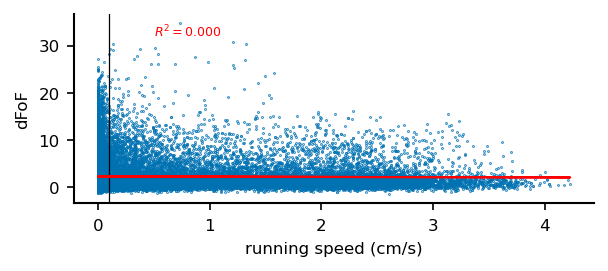

In [294]:
data.build_dFoF()
data.t_dFoF[-1]
data.build_pupil_diameter()

running_FaceCamera_sampled = data.build_running_speed(specific_time_sampling=data.t_rawFluo)
running_dFoF_sampled = data.build_running_speed(specific_time_sampling=data.t_dFoF)
pt.figure(figsize=(2,2))


roi_n = 3 #random.randint(0, data.dFoF.shape[0]-1) #90
print('Dataset : NDNF')
print('File : ', index)
print('ROI : ', roi_n)
plt.scatter(running_dFoF_sampled, data.dFoF[roi_n,:],  s=0.1)
plt.ylabel("dFoF")
plt.xlabel("running speed (cm/s)")
plt.axvline(0.1, color = 'black', label = 'threshold', linewidth=0.6)

x= np.array(running_dFoF_sampled).reshape((-1, 1))
y= np.array(data.dFoF[roi_n, :])
r_sq_s = linear_regression(x=x, 
                                y=y, 
                                ax=plt)
print("R^2 : ", f"{r_sq_s:.3f}")

In [301]:
r_sq_s_all = []

for index in range(len(SESSIONS['files'])):
    filename = SESSIONS['files'][index]
    data = Data(filename,
                verbose=False)
    data.build_dFoF()
    data.t_dFoF[-1]
    data.build_pupil_diameter()
    
    running_FaceCamera_sampled = data.build_running_speed(specific_time_sampling=data.t_rawFluo)
    running_dFoF_sampled = data.build_running_speed(specific_time_sampling=data.t_dFoF)
    
    r_sq_s = []
    
    for roi_n in range(data.dFoF.shape[0]-1): 
        x= np.array(running_dFoF_sampled).reshape((-1, 1))
        y= np.array(data.dFoF[roi_n, :])
        model = LinearRegression()
        model.fit(x,y)
        r_sq = model.score(x,y)
        r_sq_s.append(r_sq)
    
    r_sq_s_all.append(r_sq_s)


calculating dF/F with method "percentile" [...]

  ** all ROIs passed the positive F0 criterion ** 

-> dFoF calculus done !  (calculation took 0.0s)

calculating dF/F with method "percentile" [...]

  ** 11 ROIs were discarded with the positive F0 criterion (23.4%) ** 

-> dFoF calculus done !  (calculation took 0.0s)

calculating dF/F with method "percentile" [...]

  ** 2 ROIs were discarded with the positive F0 criterion (2.9%) ** 

-> dFoF calculus done !  (calculation took 0.1s)

calculating dF/F with method "percentile" [...]

  ** 30 ROIs were discarded with the positive F0 criterion (17.4%) ** 

-> dFoF calculus done !  (calculation took 0.1s)

calculating dF/F with method "percentile" [...]

  ** 26 ROIs were discarded with the positive F0 criterion (6.4%) ** 

-> dFoF calculus done !  (calculation took 0.0s)

calculating dF/F with method "percentile" [...]

  ** 23 ROIs were discarded with the positive F0 criterion (7.4%) ** 

-> dFoF calculus done !  (calculation took 0.0s

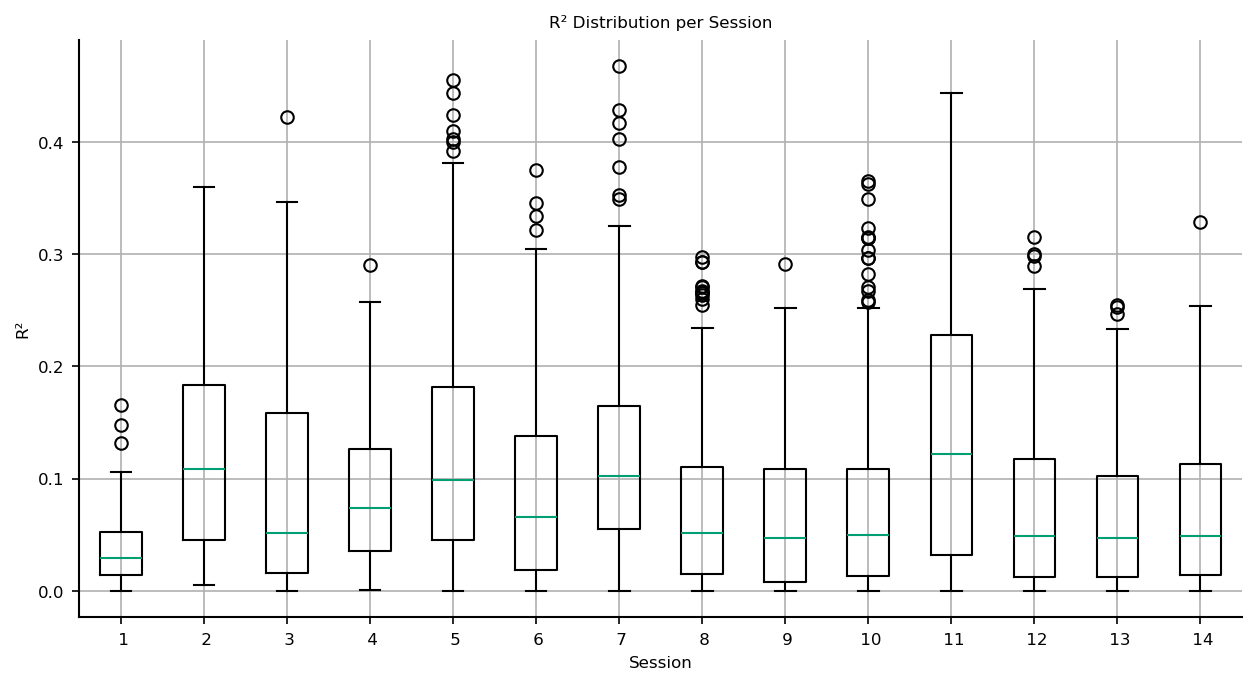

In [303]:
plt.figure(figsize=(10, 5))
plt.boxplot(r_sq_s_all)
plt.xlabel('Session')
plt.ylabel('R²')
plt.title('R² Distribution per Session')
plt.xticks(ticks=range(1, len(SESSIONS['files'])+1), labels=[f' {i+1}' for i in range(len(SESSIONS['files']))])
plt.grid(True)
plt.show()

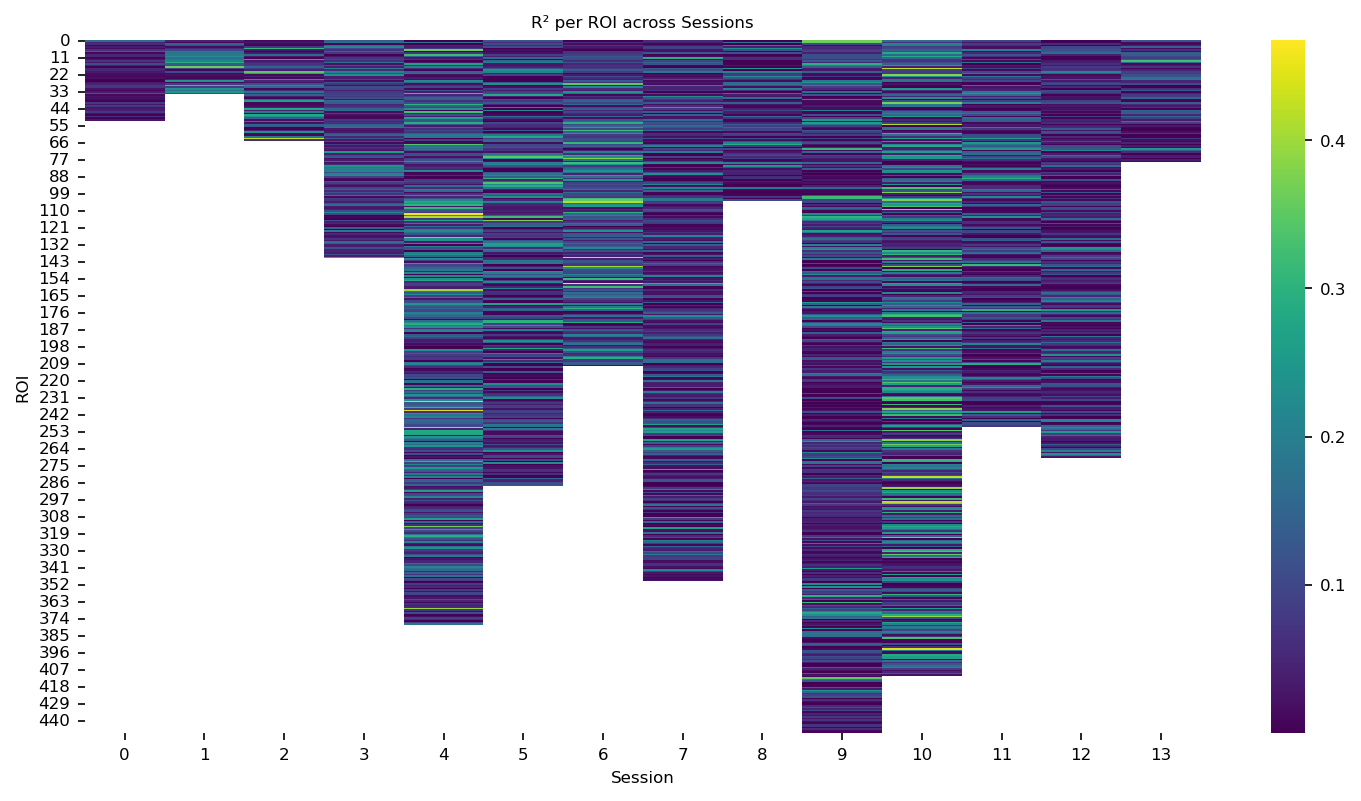

In [305]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Find the maximum number of ROIs across sessions
max_rois = max(len(r_sq_s) for r_sq_s in r_sq_s_all)

# Pad each list with np.nan to make them equal length
r_sq_array = np.array([r_sq_s + [np.nan] * (max_rois - len(r_sq_s)) for r_sq_s in r_sq_s_all]).T

# Plot heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(r_sq_array, annot=False, cmap='viridis', cbar=True)
plt.xlabel('Session')
plt.ylabel('ROI')
plt.title('R² per ROI across Sessions')
plt.show()


calculating dF/F with method "percentile" [...]

  ** all ROIs passed the positive F0 criterion ** 

-> dFoF calculus done !  (calculation took 0.0s)


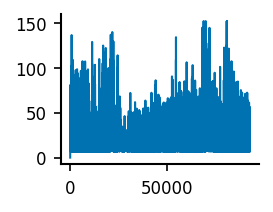

In [17]:
data.build_dFoF()
data.t_dFoF[-1]
data.build_pupil_diameter()
data.build_facemotion()
data.facemotion
plt.plot(data.facemotion)
#running_pupil_diameter_sampled = data.build_pupil_diameter()
#running_dFoF_sampled = data.build_running_speed(specific_time_sampling=data.t_dFoF)
#pt.figure(figsize=(2,2))
#plt.scatter(data., running_dFoF_sampled)

### example dFoF of one roi accros time

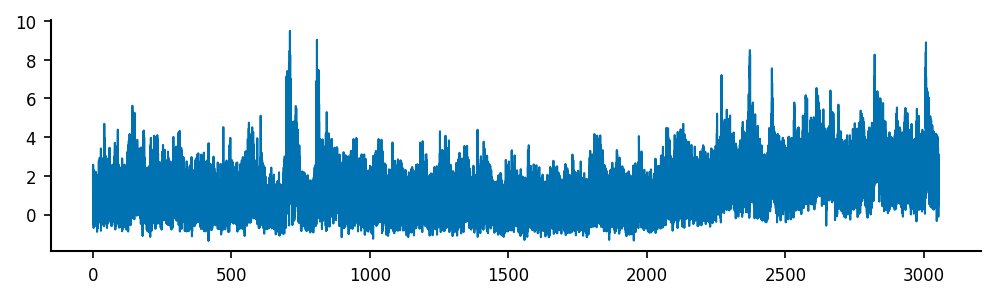

In [29]:
from matplotlib.pyplot import figure
fig = figure(figsize=(8, 2))
plt.plot(data.t_dFoF, data.dFoF[25])

(27, 89818)
89818
bin : [ 0  ;  8 ]
[1.335251   1.3859171  0.914723   0.62640136 0.50335526 0.78435236
 0.49135113 0.9752316 ]


ValueError: x and y must have same first dimension, but have shapes (8,) and (1,)

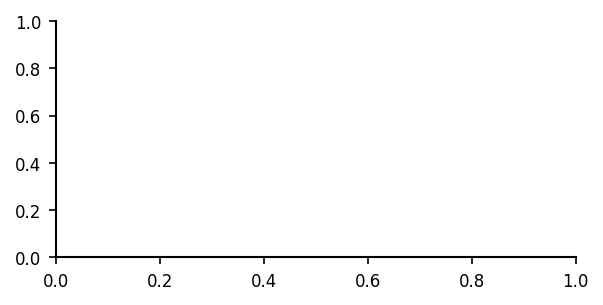

In [32]:
print(data.dFoF.shape) # (rois, time samples)
n_episodes = data.dFoF.shape[1]
bins = 40
roi = 1

print(n_episodes)
#bin_size = int(np.round(n_episodes/bins))
bin_size = 8


fig, ax = pt.figure(figsize=(2, 2.5))
for i in range(bins):
    print("bin : [", i*bin_size," ; ", (1+i)*bin_size, "]")
    print(data.dFoF[roi,i*bin_size:(1+i)*bin_size])
    temp = data.dFoF[roi,i*bin_size:(1+i)*bin_size]
    ax.plot(data.t_dFoF[i*bin_size:(1+i)*bin_size] ,temp.mean(axis=0), color=pt.get_linear_colormap('y', 'b')(i/4))

In [7]:
data.metadata

{'config': 'Yann-A1-2P',
 'date': '2024_10_07',
 'time': '16-26-15',
 'protocol': 'injection-monitoring',
 'VisualStim': True,
 'recording': '',
 'notes': 'Ketamine injection 16:19',
 'FOV': '',
 'subject_ID': 'demo-Mouse',
 'NIdaq-acquisition-frequency': 10000,
 'NIdaq-analog-input-channels': 1,
 'NIdaq-digital-input-channels': 2,
 'Rig': 'ICM-A1-2P-setup',
 'Screen': 'Dell-2020',
 'Z-sign-correction-for-rig': -1,
 'FaceCamera-frame-rate': 30,
 'FaceCamera-1cm-in-pix': 480,
 'RigCamera-frame-rate': 20,
 'RigCamera-1cm-in-pix': 33,
 'Height-of-Microscope-Camera-Image-in-mm': 2.7,
 'rotating-disk': {'radius-position-on-disk-cm': 9.0,
  'roto-encoder-value-per-rotation': -25300.0},
 'root_datafolder': 'DATA',
 'subjects_folder': 'Yann',
 'experimenter': 'Yann Zerlaut',
 'lab': 'Rebola and Bacci labs',
 'institution': 'Institut du Cerveau et de la Moelle, Paris',
 'protocols': array(['injection-monitoring'], dtype='<U20'),
 'Locomotion': True,
 'FaceCamera': True,
 'RigCamera': False,
 'N

In [33]:
data.init_visual_stim()

## Episode visualization

An episode is the presentation of a stimulus. In this case there are 8 episodes (images of gratings with 8 different angles)

In [35]:
ep = EpisodeData(data,
                 prestim_duration=2,
                 protocol_id=0,
                 quantities=['dFoF'])

  Number of episodes over the whole recording: 304/304 (with protocol condition)
  building episodes with 1 modalities [...]
  -> [ok] episodes ready !


Specific ROI, 8 orientations

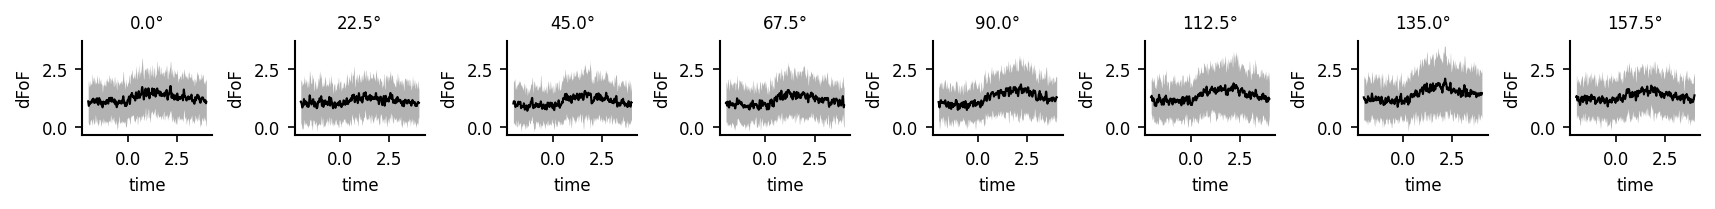

In [45]:
n_ori = 8
fig, AX = pt.figure(axes=(n_ori,1))
roi=15
for angle, ax in zip(np.unique(ep.angle), AX):
    pt.plot(ep.t, 
            ep.dFoF[ep.angle==angle, roi, :].mean(axis=0), 
            sy=ep.dFoF[ep.angle==angle, roi, :].std(axis=0), 
            ax=ax, title='%.1fdeg'%angle)
    ax.set_xlabel("time (s)")
    ax.set_ylabel("dFoF")
    ax.set_title('%.1f°' % angle)
    
pt.set_common_ylims(AX)

All ROI averaged, 8 orientations

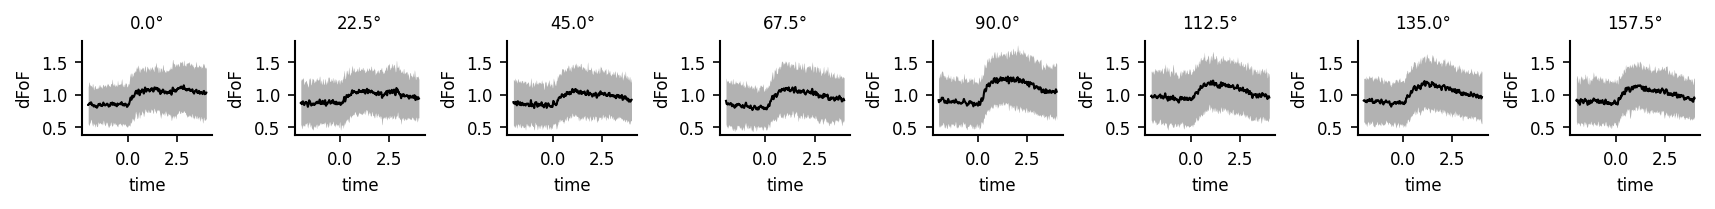

In [49]:
n_ori = 8
fig, AX = pt.figure(axes=(n_ori,1))
for angle, ax in zip(np.unique(ep.angle), AX):
    pt.plot(ep.t, 
            ep.dFoF[ep.angle==angle, :, :].mean(axis=1).mean(axis=0), 
            sy=ep.dFoF[ep.angle==angle, :, :].mean(axis=1).std(axis=0), 
            ax=ax, title='%.1fdeg'%angle)
    ax.set_xlabel("time (s)")
    ax.set_ylabel("dFoF")
    ax.set_title('%.1f°' % angle)
    
pt.set_common_ylims(AX)

#plot_trial_average(ep, column_key='angle')    #the same but visual is less good

All ROI averaged

(304, 27, 5998)
2
(304, 5998)


Text(0, 0.5, 'dFoF')

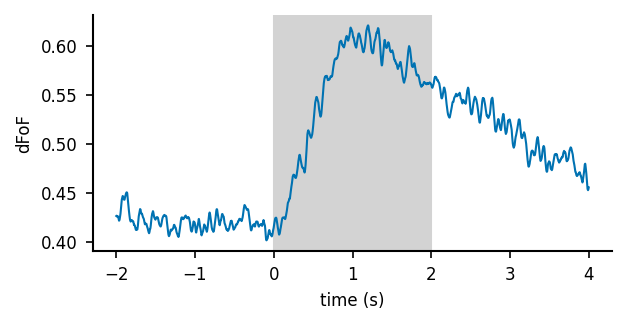

In [65]:
print(ep.dFoF.shape) # (trials, rois, time samples)
n_episodes = ep.dFoF.shape[0]
#roi = random.randint(0, ep.dFoF.shape[1]-1)  #chosen randomly
roi=2
print(roi)

fig, ax = pt.figure(figsize=(2, 2.5))
temp = ep.dFoF[:,roi,:]
print(temp.shape)
ax.plot(ep.t, temp.mean(axis=0)) #mean of all the episodes
ax.axvspan(0,2, color='lightgrey')
ax.set_xlabel("time (s)")
ax.set_ylabel("dFoF")

## Plot episodes averaging with bins

See evolution with time of dFoF

(304, 27, 5998)
3


Text(0, 0.5, 'dFoF')

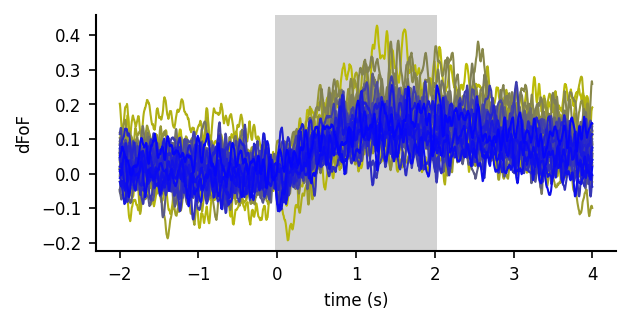

In [71]:
print(ep.dFoF.shape) # (trials, rois, time samples)
n_episodes = ep.dFoF.shape[0]
roi = 3 # random.randint(0, 26)

bin_size = 8
bins = int(n_episodes/bin_size)

norm_cond = (ep.t>-0.1) & (ep.t<0)
fig, ax = pt.figure(figsize=(2, 2.5))
print(roi)

for i in range(bins):
    #print("bin : [", i*bin_size," ; ", (1+i)*bin_size, "]")
    #temp = ep.dFoF[i*bin_size:(1+i)*bin_size,:,:].mean(axis=1).mean(axis=0)
    temp = ep.dFoF[i*bin_size:(1+i)*bin_size,roi,:].mean(axis=0)
    ax.plot(ep.t, temp-temp[norm_cond].mean(), color=pt.get_linear_colormap('y', 'b')(i/bins))  #align at stimulus presentation
    #ax.plot(ep.t, temp, color=pt.get_linear_colormap('y', 'b')(i/bins))
    ax.axvspan(0, 2, color='lightgrey')
ax.set_xlabel("time (s)")
ax.set_ylabel("dFoF")

In [72]:
def find_peak(ep, duration, roi=0):
    return ep.dFoF[:, roi, (ep.t>0) & (ep.t<duration) ].mean(axis=0).max()

In [73]:
find_peak(ep, duration=2, roi=0)

np.float64(0.47915186861463405)

In [258]:
tStart = 0
tStop = data.metadata['presentation-duration']

In [293]:
data = Data(fns[2], verbose=False)

In [300]:
data.build_dFoF(method_for_F0='sliding_percentile',
                verbose=True, 
                with_correctedFluo_and_F0=True, 
                percentile=10,
                sliding_window=5*60) #10min


calculating dF/F with method "sliding_percentile" [...]

  ** all ROIs passed the positive F0 criterion ** 

-> dFoF calculus done !  (calculation took 0.2s)


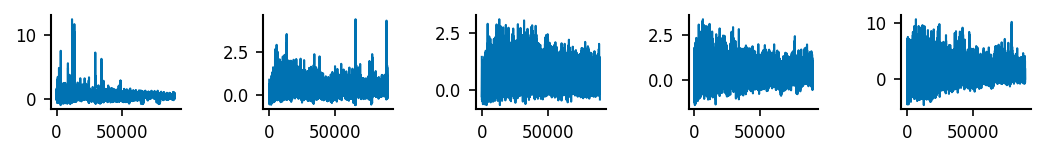

In [301]:
fig, AX = pt.figure(axes=(5,1))
for i in range(5):
    AX[i].plot(data.dFoF[i,:])